In [1]:
import torch
import math
import matplotlib.pyplot as plt

from src.concaves.log import LogConcave

from src.diffeomorphisms.composition import CompositionDiffeomorphism
from src.diffeomorphisms.vector.star import StarVectorDiffeomorphism
from src.diffeomorphisms.vector.concave import ConcaveVectorDiffeomorphism

from src.distributions.stars.ellipsoid.multimodal import MultiModalEllipsoidStarDistribution

from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean


In [2]:
mu_1 = torch.tensor([1.0, 1.0])
mu_2 = torch.tensor([-1.0, -1.0])
mu_3 = torch.tensor([1.0, -1.0])
mu_4 = torch.tensor([-1.0, 1.0])
mus = [mu_1, mu_2, mu_3, mu_4]
cov = torch.tensor([[0.25, 0.0], [0.0, 0.25]])
p = 0.95

In [3]:
multi_dist = MultiModalEllipsoidStarDistribution(covs=[cov, cov, cov, cov], mus=mus, trimmed=True, aggregation='softmax')

/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/.venv/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


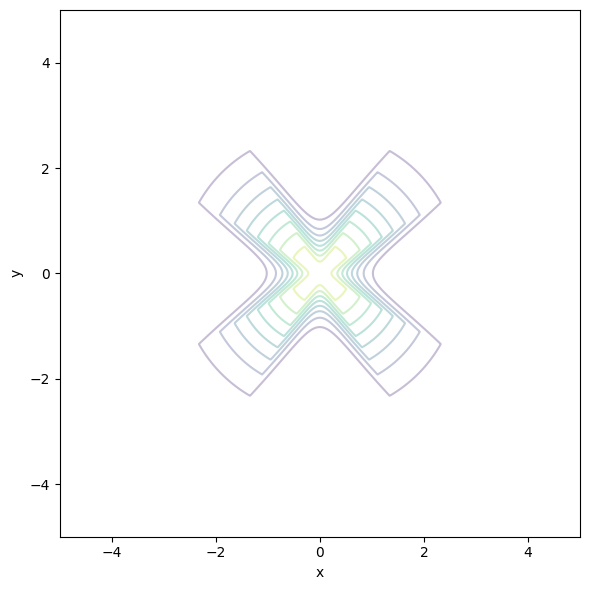

In [4]:
n_points = 1001
x = torch.linspace(-5, 5, n_points)
y = torch.linspace(-5, 5, n_points)
X, Y = torch.meshgrid(x, y)
XY = torch.stack([X.flatten(), Y.flatten()], dim=-1)
log_probs_multi = torch.exp(multi_dist.log_prob(XY).reshape(n_points, n_points).detach())


plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.tight_layout()
plt.show()

In [ ]:
phi = StarVectorDiffeomorphism(2, multi_dist)
psi = ConcaveVectorDiffeomorphism(2, LogConcave(a=10.))
Phi = CompositionDiffeomorphism([phi, psi])
phi_manifold = StandardPullbackVectorEuclidean(phi)
Phi_manifold = StandardPullbackVectorEuclidean(Phi)

/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_19976/800548984.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


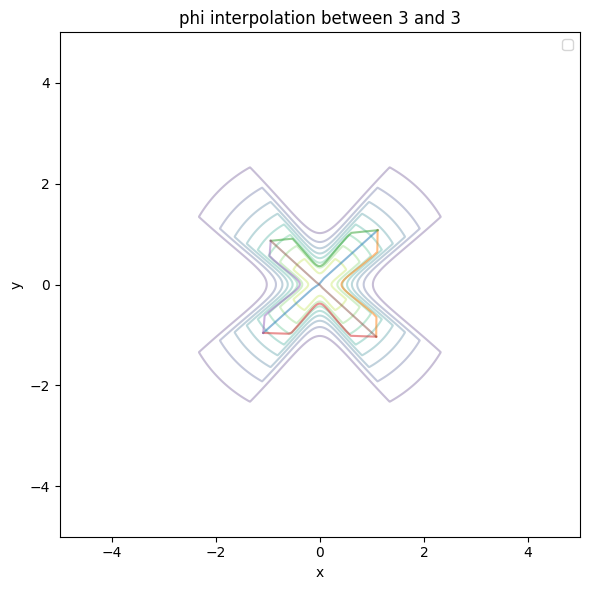

/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_19976/800548984.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


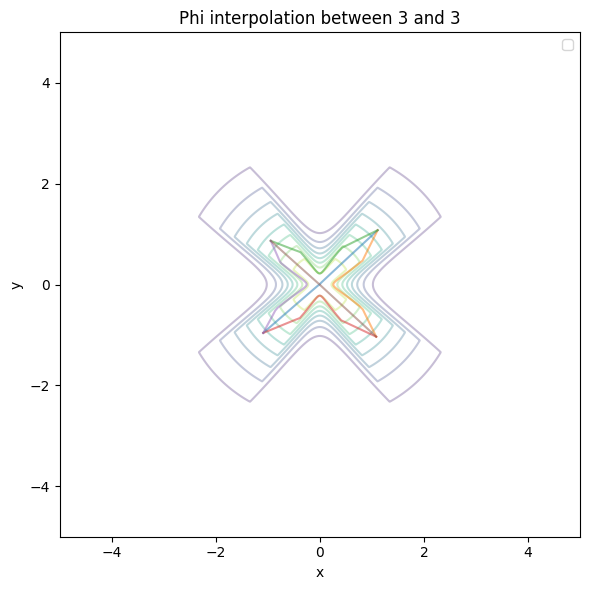

In [6]:
t = torch.linspace(0, 1, 50)

mu_noise = 0.1 * torch.randn_like(torch.stack(mus))
mus_noisy = [mu + mu_noise[i] for i, mu in enumerate(mus)]

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)

for i in range(4):
    for j in range(i+1, 4):
        mu_i = mus_noisy[i]
        mu_j = mus_noisy[j]
        # interpolate between cluster centers
        phi_geodesics = phi_manifold.geodesic(mu_i[None,None], mu_j[None,None], t)[0,0,0]
        plt.plot(phi_geodesics[:, 0].numpy(), phi_geodesics[:, 1].numpy(), alpha=0.5)


plt.xlabel('x')
plt.ylabel('y')
plt.title(f'phi interpolation between {i} and {j}')
plt.legend()
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)

for i in range(4):
    for j in range(i+1, 4):
        mu_i = mus_noisy[i]
        mu_j = mus_noisy[j]
        # interpolate between cluster centers
        Phi_geodesics = Phi_manifold.geodesic(mu_i[None,None], mu_j[None,None], t)[0,0,0]
        plt.plot(Phi_geodesics[:, 0].numpy(), Phi_geodesics[:, 1].numpy(), alpha=0.5)


plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Phi interpolation between {i} and {j}')
plt.legend()
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.tight_layout()
plt.show()